# Lab 7: Inserting Word Embeddings with a Genetic Algorithm

Welcome to the lab! Our goal is to insert new words (e.g., from the CIFAR-100 dataset) into a pre-trained Skip-Gram model *without* having to retrain the entire model from scratch.

This is a common problem: how do you update a massive, trained model with new vocabulary?

---

### 🎯 Our Goal & Method

We will implement a **(1+$\lambda$) Evolution Strategy (ES)**, a simple Genetic Algorithm. This algorithm will "evolve" a new vector for each missing word.

The evolution will be guided by a custom **fitness function** that scores how "good" a candidate vector is. A good vector should:

1.  **Fit the Corpus:** The vector should have a high dot product with its *context* words (words it appears near) and a low dot product with *negative samples* (random words). This is the core idea of Skip-Gram.
2.  **Match the Space:** The vector's **norm** (length) should be similar to the average norm of existing words. This helps it "fit in" to the pre-existing geometric structure.
3.  **Match Semantics:** The vector should be close to known "anchor" words (e.g., we can manually specify that 'beaver' should be near 'animal').

### 👩‍💻 Your Task

You will implement the core functions in `lab6.py`. This notebook will then use your functions to:
* Load the pre-trained model and data.
* Analyze the vocabulary overlap to find missing words.
* Extract contexts for the missing words.
* Run your Genetic Algorithm to evolve new embeddings.
* Analyze and visualize the newly inserted words.

In [1]:
# =============================================================================
# SETUP & IMPORTS
# =============================================================================
import os
import random
import numpy as np
import torch

# --- Imports from Previous Labs ---
# We rely on text processing tools from Lab 2 and Lab 6
from lab2 import process_text_network
from lab6 import (
    prepare_visual_genome_text,
    filter_punctuation_from_network,
    analyze_embeddings,
    find_similar_words
)

# --- Imports for Lab 7 (Genetic Algorithm) ---
# These functions handle the core Evolutionary Strategy logic,
# data loading for CIFAR-100, and visualization tools.
from lab7 import (
    load_trained_model,
    create_mappings,
    compute_embedding_stats,
    get_cifar100_vocabulary,
    analyze_vocabulary_overlap,
    extract_word_contexts,
    evolve_embedding,           # <--- The core GA function you will implement/use
    visualize_with_inserted_words,
    run_sanity_checks
)

In [2]:
# =============================================================================
# CONFIGURATION & HYPERPARAMETERS
# =============================================================================
# This cell defines all the key parameters for our experiment.
#
# -----------------------------------------------------------------------------
# 📖 TUNING NOTE:
# The `ga_...` parameters and `fitness_weights` are the most
# interesting ones to experiment with. Small changes here can
# significantly alter the final position and quality of the
# inserted embeddings.
# -----------------------------------------------------------------------------


# --- 1. File & Data Paths ---
# Defines where to load the pre-trained model from and where to find
# the corpus text data.
model_path = 'baseline_model.pth'
text_file = 'vg_text.txt'
zip_url = "https://homes.cs.washington.edu/~ranjay/visualgenome/data/dataset/region_descriptions.json.zip"

# --- 2. Pre-trained Model Parameters ---
# These parameters MUST match the architecture of the 'baseline_model.pth'
# that we are loading.
rare_threshold = 0.00025    # Filtering threshold used to train the model
embedding_dim = 64         # Dimensionality of the embedding vectors
dropout = 0.3              # Dropout rate of the loaded model
punctuation_tokens = {'.', ',', '<RARE>', "'"} # Tokens to ignore

# --- 3. Target Words & Semantic Anchors ---
# These are the *new* words we want to insert. For this first test,
# we use a small, manually-defined list.
target_words = ['wolf', 'tiger', 'rocket', 'tractor', 'rose', 'castle']

# **Semantic Anchors**: This is our "human-in-the-loop" guidance.
# We are giving the GA a hint: "the new vector for 'wolf' should be
# semantically close to the existing vectors for 'dog', 'bear', etc."
# The fitness function will reward candidates that are close to these.
anchors = {
    'wolf': ['dog', 'bear', 'animal', 'cat'],
    'tiger': ['cat', 'bear', 'animal', 'dog', 'zebra'],
    'rocket': ['plane', 'airplane', 'sky', 'flying'],
    'tractor': ['truck', 'car', 'vehicle', 'bus'],
    'rose': ['flower', 'flowers', 'plant', 'red'],
    'castle': ['building', 'house', 'wall', 'tower'],
}

# --- 4. Genetic Algorithm (ES) Parameters ---
context_window = 5         # (Window for context extraction, from Lab 6)

ga_pop_size = 100          # Population size (λ in 1+λ).
                           # We create 100 "offspring" per generation.
ga_generations = 300       # Number of evolutionary cycles to run.
ga_mutation_factor = 0.05  # The "step size" of the mutation. This is
                           # scaled by the embedding space's global
                           # standard deviation.

# --- 5. Fitness Function Weights ---
# **This is the most critical part!**
# These weights define the "goal" of the evolution. They control the
# trade-off between the three parts of our fitness function.
fitness_weights = {
    # 60% priority: Fit the corpus (Skip-Gram objective).
    'corpus': 0.60,

    # 15% priority: Match the "shape" of the space.
    # (i.e., new vectors should have a similar norm/length).
    'norm': 0.15,

    # 25% priority: Be close to our semantic anchors.
    'anchor': 0.25
}

print("✓ All configurations set.")
print(f"  Targets: {', '.join(target_words)}")
print(f"  GA Config: {ga_pop_size} population, {ga_generations} generations")
print(f"  Fitness Weights: Corpus={fitness_weights['corpus']}, "
      f"Norm={fitness_weights['norm']}, "
      f"Anchor={fitness_weights['anchor']}")

✓ All configurations set.
  Targets: wolf, tiger, rocket, tractor, rose, castle
  GA Config: 100 population, 300 generations
  Fitness Weights: Corpus=0.6, Norm=0.15, Anchor=0.25


In [3]:
# =============================================================================
# STAGE 1: LOAD CORPUS & BUILD VOCABULARY
# =============================================================================
# In this stage, we load the raw text corpus (Visual Genome) and process
# it to exactly match the vocabulary used to train our baseline model.
#
# We need this vocabulary ('nodes') to:
# 1. Load the pre-trained model (which requires the 'vocab_size').
# 2. Create the 'word_to_idx' and 'idx_to_word' mappings.
# 3. Extract contexts for our new words.

print("\n[STAGE 1] Loading Data & Building Vocabulary")
print("-" * 70)

# --- 1. Download or load text data ---
# We use the Visual Genome dataset as our corpus.
if not os.path.exists(text_file):
    print(f"Text file not found. Downloading corpus from {zip_url}...")
    # This function (from lab6) downloads, extracts, and cleans the text.
    text_file = prepare_visual_genome_text(
        zip_url=zip_url,
        zip_path="region_descriptions.json.zip",
        json_path="region_descriptions.json",
        output_path=text_file
    )
else:
    print(f"✓ Text file '{text_file}' already exists.")

# --- 2. Build co-occurrence network ---
# This step (from lab2) processes the entire text file, counts word
# frequencies, filters rare words, and builds the co-occurrence network.
print("\nProcessing text to build co-occurrence network...")
network_data = process_text_network(
    text_file,
    rare_threshold=rare_threshold,  # Must match the model's training
    rare_token="<RARE>",
    distance_mode="inverted",
    verbose=False  # Set to True to see progress
)

# --- 3. Filter punctuation ---
# We clean up the network by removing punctuation tokens.
network_data = filter_punctuation_from_network(
    network_data,
    punctuation_tokens=punctuation_tokens
)

# --- 4. Finalize Vocabulary ---
# The 'nodes' list from the network IS our final vocabulary.
nodes = network_data['nodes']
vocab_size = len(nodes)

print(f"\n{'-'*70}")
print(f"✓ STAGE 1 Complete: Vocabulary built.")
print(f"  Total vocabulary size (Vocab Size): {vocab_size} nodes")
print(f"  Total graph edges: {network_data['graph'].number_of_edges():,}")


[STAGE 1] Loading Data & Building Vocabulary
----------------------------------------------------------------------
✓ Text file 'vg_text.txt' already exists.

Processing text to build co-occurrence network...

🔧 PUNCTUATION FILTER:
  Removed: {',', '<RARE>', '.', "'"}
  Nodes: 458 → 455
  Edges: 50,128 → 48,764

----------------------------------------------------------------------
✓ STAGE 1 Complete: Vocabulary built.
  Total vocabulary size (Vocab Size): 455 nodes
  Total graph edges: 48,764


In [4]:
# =============================================================================
# STAGE 2: LOAD PRE-TRAINED MODEL & COMPUTE STATS
# =============================================================================
# Now we load the Skip-Gram model that was trained on the vocabulary we
# just built. We also compute the vital statistics of this embedding space.

print("\n[STAGE 2] Loading Model & Analyzing Embedding Space")
print("-" * 70)

# --- 1. Load Model & Embeddings ---
# This function loads the .pth file, initializes the SkipGramModel
# with the *exact* same architecture, and loads the trained weights.
# It then extracts the final (input) embedding matrix as a NumPy array.
model, embeddings = load_trained_model(
    model_path=model_path,
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    dropout=dropout
)

# --- 2. Create Mappings ---
# We need fast lookups between words and their corresponding index
# in the embedding matrix.
word_to_idx, idx_to_word = create_mappings(nodes)

# --- 3. Compute Embedding Space Statistics ---
# **Crucial Step for the GA:** We compute the statistics of the *existing*
# embedding space. Our fitness function will use these values to
# ensure that new, evolved vectors "fit in" with the original vectors.
#
# - 'mean_norm': The average length (L2 norm) of all existing vectors.
# - 'std_norm': The standard deviation of the vector lengths.
# - 'global_std': The standard deviation of *all* embedding values.
#                 (Used to scale the GA's mutation strength).
embedding_stats = compute_embedding_stats(embeddings)

print(f"\n{'-'*70}")
print(f"✓ STAGE 2 Complete: Model loaded and stats computed.")
print(f"  Embedding matrix shape: {embeddings.shape}")
print(f"  Key Stats for Fitness Function:")
print(f"    ├─ Mean Vector Norm: {embedding_stats['mean_norm']:.4f}")
print(f"    ├─ Std. Dev of Norms: {embedding_stats['std_norm']:.4f}")
print(f"    └─ Global Std. Dev: {embedding_stats['global_std']:.4f} (for mutation)")


[STAGE 2] Loading Model & Analyzing Embedding Space
----------------------------------------------------------------------
✓ Loaded model: 455 embeddings, dim=64

----------------------------------------------------------------------
✓ STAGE 2 Complete: Model loaded and stats computed.
  Embedding matrix shape: (455, 64)
  Key Stats for Fitness Function:
    ├─ Mean Vector Norm: 1.5114
    ├─ Std. Dev of Norms: 0.1253
    └─ Global Std. Dev: 0.1891 (for mutation)


/home/jovyan/teaching_material/ECS759P/labs/lab7.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


In [5]:
# =============================================================================
# STAGE 3: SANITY CHECKS (VERIFICATION)
# =============================================================================
# Before we start the complex GA process, let's verify that the model
# we loaded is sane and produces reasonable results.
#
# This function will:
# 1. Check model properties (e.g., it's in eval mode).
# 2. Check embedding matrix stats (e.g., no NaNs/Infs).
# 3. Print nearest neighbors for a few common words ('man', 'dog', etc.)
#    using the `find_similar_words` function from Lab 6.
#
# If the neighbors look sensible, our embedding space is good!

run_sanity_checks(model, embeddings, nodes, word_to_idx)


SANITY CHECKS

1. Model Configuration:
   Training mode: False
   Device: cuda:0

2. Embedding Quality:
   Shape: (455, 64)
   Mean: -0.013119, Std: 0.189114
   Min: -0.734299, Max: 0.787133
   Contains NaN: False, Contains Inf: False

3. Embedding Norms:
   Mean: 1.5114, Std: 0.1253
   Range: [1.2006, 1.8877]

4. Vocabulary Test:
   'man       ' → idx=   9, norm=1.7294
      Similar: woman(0.910), person(0.909), boy(0.873), girl(0.865), child(0.849)
   'woman     ' → idx=  19, norm=1.6622
      Similar: man(0.910), girl(0.868), child(0.864), person(0.863), boy(0.855)
   'dog       ' → idx=  64, norm=1.4671
      Similar: cat(0.820), bear(0.807), horse(0.804), bird(0.798), giraffe(0.793)
   'car       ' → idx=  45, norm=1.6198
      Similar: truck(0.811), train(0.797), bike(0.769), vehicle(0.761), plane(0.757)
   'blue      ' → idx=  11, norm=1.5241
      Similar: red(0.812), orange(0.810), black(0.803), pink(0.801), grey(0.768)

✓ SANITY CHECKS COMPLETE


In [6]:
# =============================================================================
# STAGE 4: DEFINE TARGET WORDS
# =============================================================================
# Our goal is to insert new words. But *which* words?
#
# This notebook is set up for two potential experiments:
# 1. Insert a small, manually-defined list ('wolf', 'tiger', etc.)
# 2. Insert all the words from CIFAR-100 that are missing from our vocab.
#
# For this lab, we will do a mix: we'll load the CIFAR-100 list to
# perform an analysis, but our *actual* target list for the GA
# will be the small, manual list we defined in the config cell.
# This lets us test the algorithm quickly on a few interesting words.

print("\n[STAGE 4] Vocabulary Analysis & Target Selection")
print("-" * 70)

# --- 1. Analysis: Compare against CIFAR-100 ---
# Let's see how many CIFAR-100 class names are missing from our
# Visual Genome vocabulary.
cifar_vocab = get_cifar100_vocabulary()

# This function prints a detailed analysis and returns the list of
# words that are in CIFAR-100 but NOT in our 'nodes' (model vocab).
missing_cifar_words = analyze_vocabulary_overlap(cifar_vocab, nodes)

# --- 2. Selection: Use the Manual List for this Run ---
# The analysis above is for your information. For this first experiment,
# we will use the 'target_words' list we defined in the config cell.
#
# We must first filter this list to make sure we don't try to
# insert a word that already exists in the vocabulary.
print(f"\nChecking our manual target list: {target_words}")

target_words_filtered = [
    w for w in target_words if w not in set(nodes)
]

if not target_words_filtered:
    print("✓ All manual target words already in vocabulary! (Nothing to do)")
elif len(target_words_filtered) < len(target_words):
    removed = set(target_words) - set(target_words_filtered)
    print(f"✓ Removed pre-existing words: {list(removed)}")
    print(f"✓ Final target words to insert: {target_words_filtered}")
else:
    print(f"✓ All {len(target_words_filtered)} manual target words are missing and will be inserted.")

# Overwrite the 'target_words' variable with our final, filtered list.
target_words = target_words_filtered


[STAGE 4] Vocabulary Analysis & Target Selection
----------------------------------------------------------------------

Loading CIFAR-100 vocabulary...
Files already downloaded and verified
✓ CIFAR-100 vocabulary loaded: 100 classes

VOCABULARY OVERLAP ANALYSIS
CIFAR-100 vocabulary: 100 classes
Network vocabulary: 455 words
Overlapping words: 32 (32.0%)
Missing from network: 68

Found: apple, baby, bear, bed, bicycle, bottle, bowl, boy, bridge, bus, can, chair, clock, cloud, couch, cup, elephant, girl, house, keyboard, lamp, man, motorcycle, mountain, mouse, orange, plate, road, table, tank, train, woman

Missing: aquarium_fish, beaver, bee, beetle, butterfly, camel, castle, caterpillar, cattle, chimpanzee, cockroach, crab, crocodile, dinosaur, dolphin, flatfish, forest, fox, hamster, kangaroo, lawn_mower, leopard, lion, lizard, lobster, maple_tree, mushroom, oak_tree, orchid, otter, palm_tree, pear, pickup_truck, pine_tree, plain, poppy, porcupine, possum, rabbit, raccoon, ray, rock

In [7]:
# =============================================================================
# STAGE 5: EXTRACT CORPUS CONTEXTS
# =============================================================================
# This is a critical data-gathering step for our Genetic Algorithm.
#
# To evaluate the 'corpus' part of our fitness function, we need to
# know which words our new target words co-occur with in the text.
#
# This function will read the entire 'vg_text.txt' corpus and find
# all co-occurrences for our 'target_words' within the specified window.
#
# It returns a dictionary, e.g.:
# contexts = {
#     'wolf': Counter({'animal': 12, 'forest': 8, ...}),
#     'tiger': Counter({'stripes': 20, 'cat': 15, ...})
# }
#
# This Counter will be used to select the positive samples (ctx_vecs)
# in the fitness function.

print("\n[STAGE 5] Extracting Corpus Contexts for Target Words")
print("-" * 70)

# We need the 'set(nodes)' to quickly check if a context word is
# actually in our vocabulary. We ignore any context words that aren't.
vocab_set = set(nodes)

contexts = extract_word_contexts(
    text_file=text_file,
    target_words=target_words,
    vocab_set=vocab_set,
    window=context_window
)

print(f"\n{'-'*70}")
print("✓ STAGE 5 Complete: Contexts extracted.")


[STAGE 5] Extracting Corpus Contexts for Target Words
----------------------------------------------------------------------
 Complete 

 Context statistics
  wolf      :    728 contexts, 152 unique words
  tiger     :   3631 contexts, 290 unique words
  rocket    :    938 contexts, 175 unique words
  tractor   :   5890 contexts, 327 unique words
  rose      :  13610 contexts, 390 unique words
  castle    :   6117 contexts, 321 unique words

----------------------------------------------------------------------
✓ STAGE 5 Complete: Contexts extracted.


# STAGE 6: THE (1+$\lambda$) EVOLUTION STRATEGY IN DETAIL

Welcome to the core of our solution: the **(1+$\lambda$) Evolution Strategy (ES)**. This powerful, yet conceptually simple, Genetic Algorithm will "evolve" a new embedding vector for each of our target words. Think of it as a guided search through the high-dimensional embedding space, aiming to find the perfect location for a new word.

---

### 🧬 Evolutionary Algorithms: A Quick Primer

Evolutionary Algorithms (EAs) are a family of optimization techniques inspired by natural evolution. They operate on a *population* of candidate solutions, which iteratively "evolve" over *generations* through processes like:

* **Initialization:** Creating the first set of candidate solutions.
* **Selection:** Choosing which solutions get to "reproduce" or survive.
* **Mutation:** Introducing random changes to create new solutions.
* **Crossover (Recombination):** Combining parts of parent solutions (not used in (1+$\lambda$) ES).
* **Fitness Evaluation:** Assigning a "quality score" to each solution.

### The (1+$\lambda$) ES: Parent-Centric Evolution

The (1+$\lambda$) ES is a specific type of EA, where:

* **1:** Represents the single **parent** solution. This is the best solution found so far.
* **$\lambda$:** Represents the number of **offspring** generated from the parent in each generation.

The process is straightforward:

1.  **Start with a Parent:** Begin with an initial candidate solution (our embedding vector).
2.  **Generate Offspring:** Create $\lambda$ new candidate solutions by adding random "noise" (mutation) to the parent.
3.  **Evaluate All:** Calculate the *fitness* of the parent and all $\lambda$ offspring.
4.  **Select New Parent:** The best solution (parent or any of the offspring) becomes the parent for the next generation. This ensures that the population always improves or stays the same.

---

### 🎯 Our Application: Evolving Word Embeddings

For our task, each "solution" is a `D`-dimensional embedding vector for a target word.

#### 1. Initialization: Bootstrapping from Contexts

How do we start a new word's journey in the embedding space? We give it a head start! The `initialize_embedding` function performs a **corpus bootstrap**:

* It finds the most frequent context words for our target word (e.g., for 'wolf', its contexts might be 'animal', 'forest', 'howl').
* It then calculates a **weighted average** of the *existing* embedding vectors of these context words.

This creates an initial vector that is already close to where it "should" be, based on its linguistic usage. If no contexts are found, it initializes to the mean of all existing embeddings.

In [8]:
# =============================================================================
# STAGE 6: RUN THE GENETIC ALGORITHM
# =============================================================================

print("\n[STAGE 6] Evolving New Embeddings via (1+λ) ES")
print("-" * 70)
print(f"Running (1 + {ga_pop_size}) Evolution Strategy for {len(target_words)} words...")
print(f"Generations per word: {ga_generations}")

inserted_embeddings_list = []
ga_config = {
    "ga_pop_size": ga_pop_size,
    "ga_generations": ga_generations,
    "ga_mutation_factor": ga_mutation_factor,
    "fitness_weights": fitness_weights
}

# --- Main Evolution Loop ---
for word in target_words:
    # Evolve the embedding for this single word
    evolved_vec = evolve_embedding(
        word,
        contexts,
        embeddings,       # The original embedding matrix
        word_to_idx,
        nodes,            # The original vocab list (for neg. sampling)
        embedding_stats,  # Stats for the 'norm' fitness term
        anchors,          # Dict of anchors for the 'anchor' fitness term
        ga_config         # All GA hyperparameters
    )
    inserted_embeddings_list.append(evolved_vec)

# --- Collect Results ---
# We now have a list of new vectors. We stack them into a NumPy
# matrix for easy analysis.
inserted_embeddings = np.array(inserted_embeddings_list)

print(f"\n{'-'*70}")
print(f"✓ STAGE 6 Complete: Evolved {len(target_words)} new embeddings.")


[STAGE 6] Evolving New Embeddings via (1+λ) ES
----------------------------------------------------------------------
Running (1 + 100) Evolution Strategy for 6 words...
Generations per word: 300

  Evolving: 'wolf' G0=0.3563 G50=0.4898 G100=0.5135 G150=0.5139 G200=0.5139 G250=0.5139 ✓ Final=0.5139

  Evolving: 'tiger' G0=0.3598 G50=0.4923 G100=0.5126 G150=0.5127 G200=0.5127 G250=0.5128 ✓ Final=0.5128

  Evolving: 'rocket' G0=0.3577 G50=0.4536 G100=0.4660 G150=0.4661 G200=0.4662 G250=0.4662 ✓ Final=0.4662

  Evolving: 'tractor' G0=0.3719 G50=0.4916 G100=0.5060 G150=0.5061 G200=0.5062 G250=0.5062 ✓ Final=0.5062

  Evolving: 'rose' G0=0.3786 G50=0.4636 G100=0.4701 G150=0.4702 G200=0.4702 G250=0.4703 ✓ Final=0.4703

  Evolving: 'castle' G0=0.3744 G50=0.4809 G100=0.4961 G150=0.4963 G200=0.4963 G250=0.4963 ✓ Final=0.4963

----------------------------------------------------------------------
✓ STAGE 6 Complete: Evolved 6 new embeddings.


In [9]:
# =============================================================================
# STAGE 7: MERGE EMBEDDINGS
# =============================================================================
# We now have two sets of embeddings:
# 1. `embeddings`: The original (N x D) matrix for the original `nodes`.
# 2. `inserted_embeddings`: Our new (K x D) matrix for the `target_words`.
#
# To analyze and visualize them together, we simply stack them into
# one large matrix and one large vocabulary list.

print("\n[STAGE 7] Combining Original and Evolved Embeddings")
print("-" * 70)

# `np.vstack` stacks the two matrices vertically, creating a
# new matrix of shape (N + K, D).
all_embeddings = np.vstack([embeddings, inserted_embeddings])

# We concatenate the vocabulary lists in the *same order*.
# - Indices 0 to N-1 correspond to the original `nodes`.
# - Indices N to N+K-1 correspond to our new `target_words`.
all_vocab = nodes + target_words

print(f"✓ Combined embedding matrix shape: {all_embeddings.shape}")
print(f"✓ Combined vocabulary size: {len(all_vocab)} words")
print(f"  ├─ Original words: {len(nodes)}")
print(f"  └─ Newly inserted words: {len(target_words)}")


[STAGE 7] Combining Original and Evolved Embeddings
----------------------------------------------------------------------
✓ Combined embedding matrix shape: (461, 64)
✓ Combined vocabulary size: 461 words
  ├─ Original words: 455
  └─ Newly inserted words: 6


In [10]:
# =============================================================================
# STAGE 8: ANALYSIS & VERIFICATION
# =============================================================================
# This is the moment of truth!
#
# We will use the `analyze_embeddings` function from Lab 6 to run a
# standard set of quality checks on our *newly combined* embedding space.
#
# We will specifically test our newly inserted words to see if they
# behave logically.
#
# 1. Similarity: We'll find the nearest neighbors for our new words.
#    (e.g., are 'dog' and 'animal' near 'wolf'?).
# 2. Analogies: We'll dynamically create analogies using our anchor list.
#    (e.g., "dog is to cat as wolf is to ???")
# 3. Clustering: We'll use our new words as seeds for clustering.

print("\n[STAGE 8] Analyzing Combined Embedding Space")
print("-" * 70)

# --- 1. Setup Similarity Test ---
# We'll just use the first few target words as examples.
similarity_examples = target_words[:3]
print(f"Running similarity checks for: {similarity_examples}")

# --- 2. Setup Analogy Test ---
# Let's auto-create analogy tasks based on our anchor list.
# e.g., if anchors['wolf'] = ['dog', 'animal', ...],
# we create the analogy ('dog', 'animal', 'wolf').
# The model should solve: "dog" - "animal" + "wolf" approx ???
analogy_examples = []
for word in target_words:
    if word in anchors and len(anchors[word]) >= 2:
        # Create an analogy: (anchor1, anchor2, new_word)
        analogy_examples.append((
            anchors[word][0],  # e.g., 'dog'
            anchors[word][1],  # e.g., 'animal'
            word               # e.g., 'wolf'
        ))
    if len(analogy_examples) >= 3:
        break  # Limit to 3 analogies for brevity
print(f"Running analogy checks for: {analogy_examples}")

# --- 3. Setup Clustering Test ---
# We'll use our newly inserted words as the seeds for clustering.
# This helps us see which original words group around our new ones.
cluster_seeds = target_words
print(f"Running clustering checks for: {cluster_seeds}")

# --- 4. Run Full Analysis ---
analyze_embeddings(
    nodes=all_vocab,  # <--- FIX: Renamed 'vocabulary' to 'nodes'
    embeddings=all_embeddings,
    similarity_examples=similarity_examples,
    analogy_examples=analogy_examples,
    cluster_seeds=cluster_seeds
)


[STAGE 8] Analyzing Combined Embedding Space
----------------------------------------------------------------------
Running similarity checks for: ['wolf', 'tiger', 'rocket']
Running analogy checks for: [('dog', 'bear', 'wolf'), ('cat', 'bear', 'tiger'), ('plane', 'airplane', 'rocket')]
Running clustering checks for: ['wolf', 'tiger', 'rocket', 'tractor', 'rose', 'castle']

EMBEDDING ANALYSIS

Vocabulary: 461  Embedding dim: 64

Similarity stats (100 word sample):
  Mean: 0.4662  Std: 0.1146
  Min: 0.1755  Max: 0.9185

NEAREST NEIGHBORS

Most similar to 'wolf':
  tiger            similarity=0.9528
  bear             similarity=0.8596
  cat              similarity=0.8106
  dog              similarity=0.8094
  animal           similarity=0.7349
  cow              similarity=0.6974
  giraffe          similarity=0.6885
  horse            similarity=0.6857

Most similar to 'tiger':
  wolf             similarity=0.9528
  bear             similarity=0.8379
  cat              similarity=0.828

In [11]:
# =============================================================================
# STAGE 9: SAVE & VERIFY FINAL MODEL
# =============================================================================
# Our experiment is complete! We have a new, larger embedding matrix
# and vocabulary list. Let's save these to a new .pth file so we
# can use them in other applications without re-running the GA.
#
# We will then immediately reload the file to verify it saved correctly.

print("\n[STAGE 9] Saving and Verifying Final Artifacts")
print("-" * 70)

# --- 1. Define Save Path ---
save_path = "skipgram_with_inserted_words.pth"

# --- 2. Combine and Save ---
# We are not saving the original PyTorch model, but rather the *results*
# of our process: the combined embedding matrix and the new vocab list.

# Combine the original 'embeddings' and our new 'inserted_embeddings'
full_embeddings = np.vstack([embeddings, inserted_embeddings])
full_embeddings_tensor = torch.tensor(full_embeddings, dtype=torch.float32)

print(f"Saving combined model to {save_path}...")
torch.save({
    # The (N+K, D) embedding matrix
    'embeddings': full_embeddings_tensor,

    # The (N+K) vocabulary list
    'vocab': all_vocab,

    # Just the list of words we inserted
    'inserted_words': target_words,

    # Metadata for quick loading
    'metadata': {
        'n_original': len(nodes),
        'n_inserted': len(target_words),
        'vocab_size': len(all_vocab),
        'embedding_dim': inserted_embeddings.shape[1]
    }
}, save_path)

print(f"✓ Model saved to: {save_path}")

# ============================================================================
# VERIFICATION: RELOAD AND TEST
# ============================================================================
# Let's confirm the file is valid by loading it and running the
# neighbor-finding test on both original *and* inserted words.

print("\nReloading model for verification...")

# --- 1. Reload Checkpoint ---
checkpoint = torch.load(save_path, map_location='cpu')
loaded_embeddings = checkpoint['embeddings'].numpy()
loaded_vocab = checkpoint['vocab']
loaded_inserted = checkpoint['inserted_words']

print(f"✓ Model reloaded. Vocab: {len(loaded_vocab)}, Inserted: {len(loaded_inserted)}")

# --- 2. Run Vocabulary Test ---
# This test now includes our newly evolved words.
print("\n" + "="*70)
print("Final Vocabulary Test (Original + Inserted)")
print("="*70)

# We'll test a mix of original words and our new target words
test_words = [
    'man', 'woman', 'dog', 'car', 'blue',  # Original words
] + target_words  # Our new words

for word in test_words:
    if word not in loaded_vocab:
        print(f"   '{word:10s}' → Not in vocabulary.")
        continue

    # Find the word's index and vector
    idx = loaded_vocab.index(word)
    norm = np.linalg.norm(loaded_embeddings[idx])

    # Use lab6's 'find_similar_words' on our fully combined data
    similar = find_similar_words(word, loaded_vocab, loaded_embeddings, top_k=5)

    if not similar:
        print(f"   '{word:10s}' → idx={idx:4d}, norm={norm:.4f} (No neighbors found?)")
        continue

    neighbor_str = ', '.join([f"{w}({s:.3f})" for w, s in similar])

    print(f"   '{word:10s}' → idx={idx:4d}, norm={norm:.4f}")
    print(f"      Similar: {neighbor_str}\n")

print("\n" + "="*70)
print("✓ Vocabulary Test Complete")
print("="*70)


[STAGE 9] Saving and Verifying Final Artifacts
----------------------------------------------------------------------
Saving combined model to skipgram_with_inserted_words.pth...
✓ Model saved to: skipgram_with_inserted_words.pth

Reloading model for verification...
✓ Model reloaded. Vocab: 461, Inserted: 6

Final Vocabulary Test (Original + Inserted)
   'man       ' → idx=   9, norm=1.7294
      Similar: woman(0.910), person(0.909), boy(0.873), girl(0.865), child(0.849)

   'woman     ' → idx=  19, norm=1.6622
      Similar: man(0.910), girl(0.868), child(0.864), person(0.863), boy(0.855)

   'dog       ' → idx=  64, norm=1.4671
      Similar: cat(0.820), wolf(0.809), bear(0.807), horse(0.804), tiger(0.803)

   'car       ' → idx=  45, norm=1.6198
      Similar: tractor(0.835), truck(0.811), train(0.797), bike(0.769), vehicle(0.761)

   'blue      ' → idx=  11, norm=1.5241
      Similar: red(0.812), orange(0.810), black(0.803), pink(0.801), grey(0.768)

   'wolf      ' → idx= 455, no

/tmp/ipykernel_1201/1926017878.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path, map_location='cpu')



[STAGE 10] Visualizing Combined Embedding Space
----------------------------------------------------------------------

Generating t-SNE visualization with inserted words...
✓ Saved t-SNE to embeddings_with_inserted.png


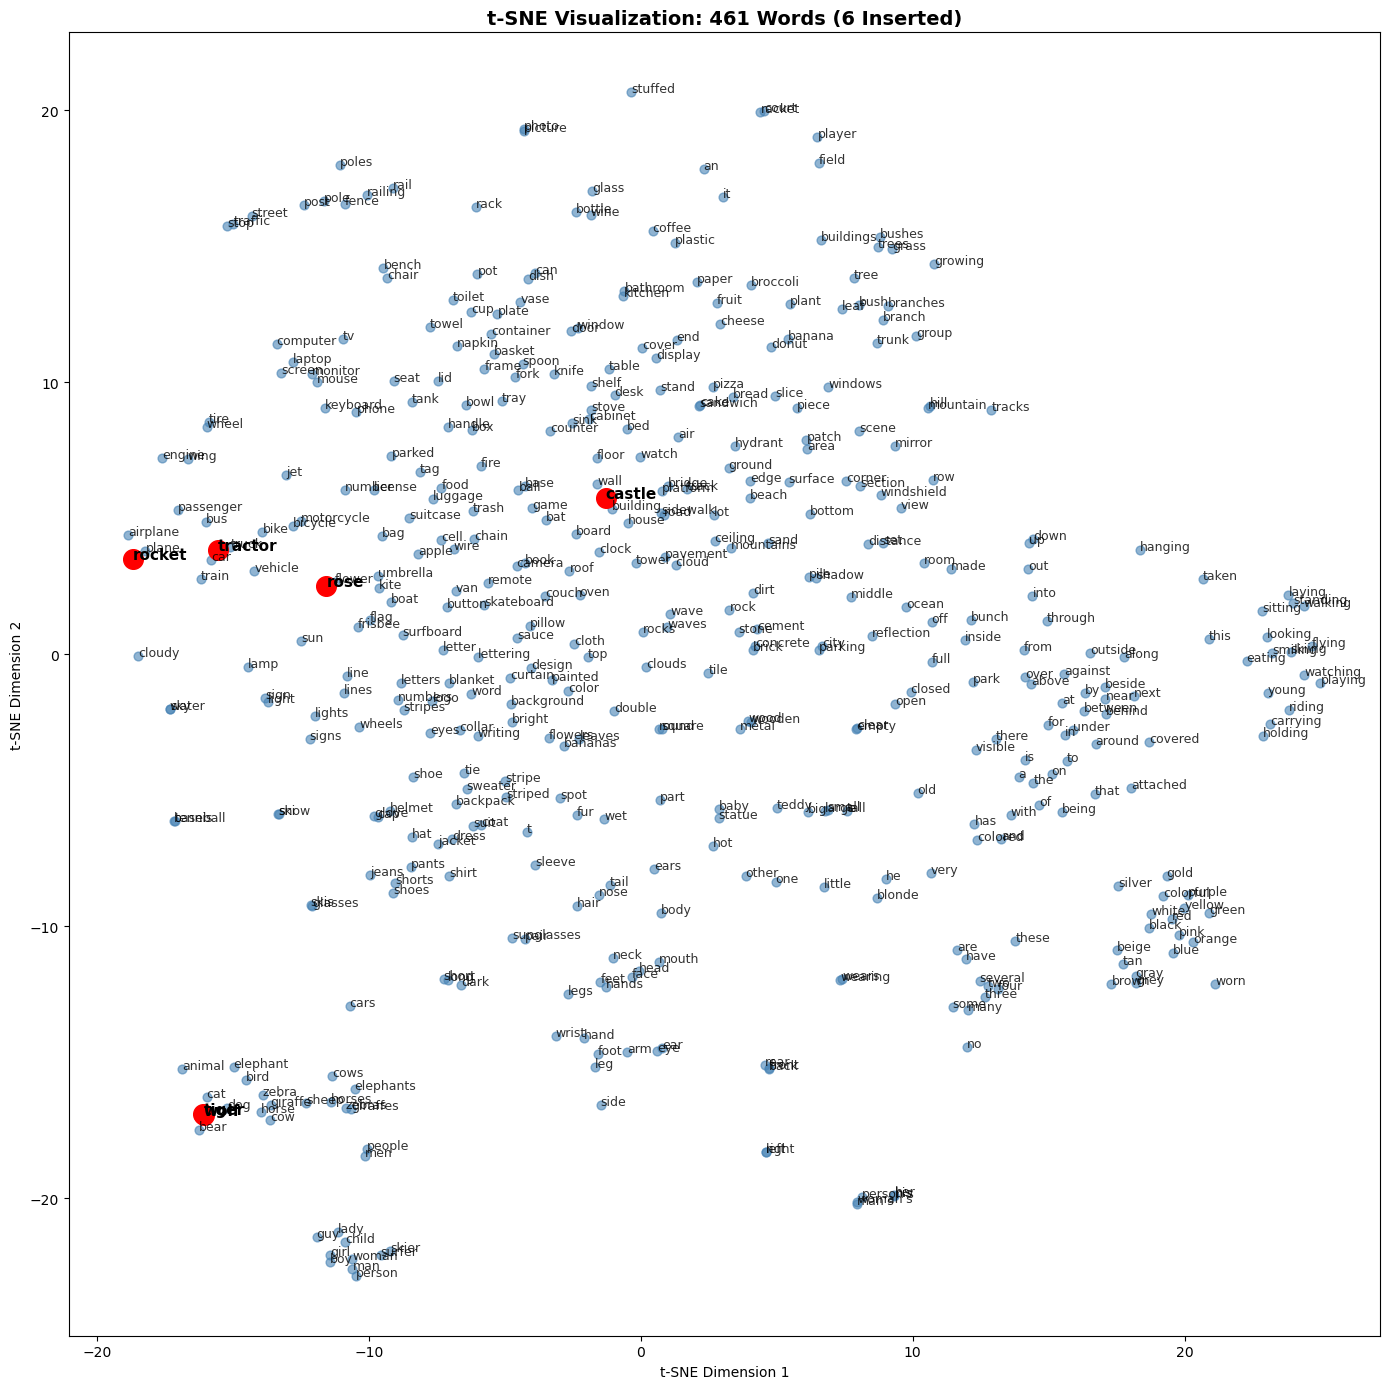


✓ PIPELINE COMPLETE
Inserted words: wolf, tiger, rocket, tractor, rose, castle
New vocabulary size: 461 words

💡 Key Insights:
  • (1+100) ES successfully evolved 6 embeddings.
  • The Lab 6 analysis report (Stage 8) quantitatively checks quality.
  • The t-SNE plot above (Stage 10) visually confirms semantic coherence.


In [12]:
# =============================================================================
# STAGE 10: VISUALIZATION & FINAL SUMMARY
# =================================_===========================================
#
# Our final step is to visualize the combined embedding space using t-SNE.
# This special visualization function will highlight our newly inserted
# words in red, allowing us to *visually inspect* whether they landed in
# semantically appropriate regions of the space.
#
# e.g., Did 'wolf' and 'tiger' land near other 'animal' words?
#       Did 'rocket' land near 'plane'?
#       Did 'castle' land near 'building' or 'house'?

print("\n[STAGE 10] Visualizing Combined Embedding Space")
print("-" * 70)

visualize_with_inserted_words(
    nodes=all_vocab,
    embeddings=all_embeddings,
    inserted_words=target_words,
    output_file="embeddings_with_inserted.png",
    sample_size=500  # Sample 500 words, including all our inserted ones
)

# --- 11. Final Summary ---
# Finally, let's print a summary of the entire run.

print("\n" + "="*70)
print("✓ PIPELINE COMPLETE")
print("="*70)

print(f"Inserted words: {', '.join(target_words)}")
print(f"New vocabulary size: {len(all_vocab)} words")

print("\n💡 Key Insights:")
print(f"  • (1+{ga_pop_size}) ES successfully evolved {len(target_words)} embeddings.")
print("  • The Lab 6 analysis report (Stage 8) quantitatively checks quality.")
print("  • The t-SNE plot above (Stage 10) visually confirms semantic coherence.")
print("="*70)

In [12]:
from lab7 import run_tests

run_tests()

test_no_context_returns_mean (lab7.TestEmbeddingInit.test_no_context_returns_mean) ... ok
test_with_context_weighted_average (lab7.TestEmbeddingInit.test_with_context_weighted_average) ... ok
test_fitness_range (lab7.TestFitness.test_fitness_range) ... ok
test_extract_word_contexts (lab7.TestContextExtraction.test_extract_word_contexts) ... ok
test_shapes (lab7.TestPrecomputeVectors.test_shapes) ... ok
test_smoke_run (lab7.TestEvolveEmbedding.test_smoke_run) ... ERROR

ERROR: test_smoke_run (lab7.TestEvolveEmbedding.test_smoke_run)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/jovyan/teaching_material/ECS759P/labs/lab7.py", line 684, in test_smoke_run
    stats_dict = {'mean_norm':1.0, 'std_norm':0.5, 'global_std':0.5}
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jovyan/teaching_material/ECS759P/labs/lab7.py", line 495, in evolve_embedding
    ctx_vecs, ctx_weights, neg_vecs

 Complete 

 Context statistics
  fox       :      4 contexts,   4 unique words

  Evolving: 'w0'

False